In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

In [2]:
ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/kenya_clean.csv'

In [3]:
import os
os.listdir("../data")

['Data Legend.txt',
 'ethiopia.csv',
 'ethiopia_clean.csv',
 'kenya.csv',
 'nigeria.csv',
 'sudan.csv',
 'tanzania.csv']

In [4]:
import pandas as pd
import numpy as np

countries = ["ethiopia","kenya","sudan","tanzania","nigeria"]

for country in countries:
    
    df = pd.read_csv(f"../data/{country}.csv")
    
    # replace missing value code
    df.replace(-999, np.nan, inplace=True)
    
    # create date
    df["Date"] = pd.to_datetime(df["YEAR"]*1000 + df["DOY"], format="%Y%j")
    
    # extract month
    df["Month"] = df["Date"].dt.month
    
    # forward fill missing values
    df.fillna(method="ffill", inplace=True)
    
    # save cleaned file
    df.to_csv(f"../data/{country}_clean.csv", index=False)

print("All cleaned datasets created")

TypeError: NDFrame.fillna() got an unexpected keyword argument 'method'

In [5]:
import pandas as pd
import numpy as np

countries = ["ethiopia","kenya","sudan","tanzania","nigeria"]

for country in countries:

    df = pd.read_csv(f"../data/{country}.csv")

    # replace missing values
    df.replace(-999, np.nan, inplace=True)

    # create date
    df["Date"] = pd.to_datetime(df["YEAR"]*1000 + df["DOY"], format="%Y%j")

    # extract month
    df["Month"] = df["Date"].dt.month

    # forward fill missing values
    df = df.ffill()

    # save cleaned dataset
    df.to_csv(f"../data/{country}_clean.csv", index=False)

print("All cleaned datasets created successfully")

All cleaned datasets created successfully


In [6]:
ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")

In [7]:
ethiopia["Country"] = "Ethiopia"
kenya["Country"] = "Kenya"
sudan["Country"] = "Sudan"
tanzania["Country"] = "Tanzania"
nigeria["Country"] = "Nigeria"

In [8]:
df = pd.concat([ethiopia, kenya, sudan, tanzania, nigeria])
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,2015-01-01,1,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,2015-01-02,1,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,2015-01-03,1,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,2015-01-04,1,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,2015-01-05,1,Ethiopia


In [9]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

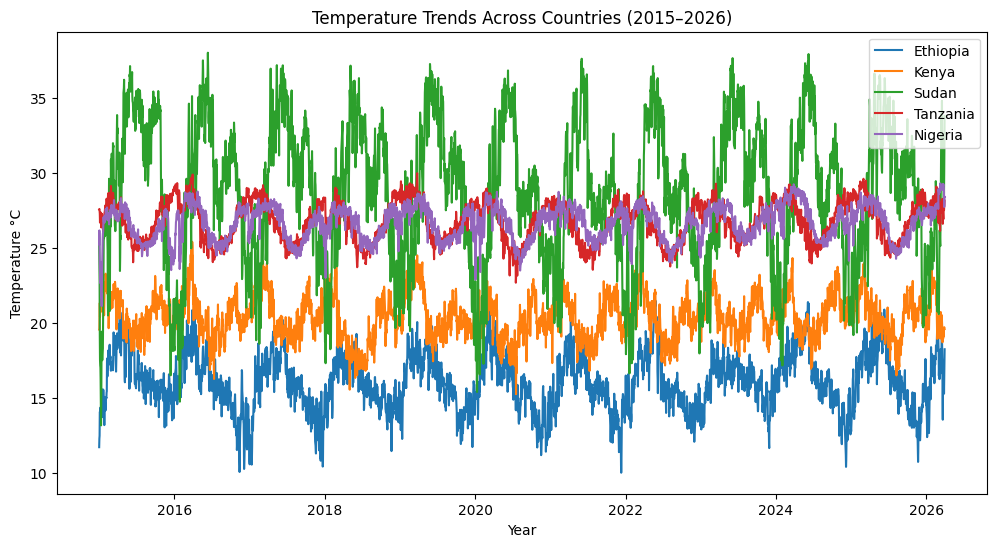

In [10]:
monthly_temp = df.groupby(["Country","Date"])["T2M"].mean().reset_index()

plt.figure(figsize=(12,6))

for country in df["Country"].unique():
    country_data = monthly_temp[monthly_temp["Country"] == country]
    plt.plot(country_data["Date"], country_data["T2M"], label=country)

plt.title("Temperature Trends Across Countries (2015–2026)")
plt.xlabel("Year")
plt.ylabel("Temperature °C")
plt.legend()
plt.show()

In [11]:
temp_summary = df.groupby("Country")["T2M"].agg(["mean","median","std"])
temp_summary

,mean,median,std
Country,,,
Ethiopia,16.068500,16.04,1.898050
Kenya,20.427600,20.36,1.440824
Nigeria,26.656928,26.82,1.123335
Sudan,28.759007,29.16,4.681305
Tanzania,26.802422,26.99,1.325388


Sudan and Tanzania show the highest average temperatures.
Ethiopia and Kenya have relatively lower mean temperatures.
Sudan also exhibits the highest temperature variability.

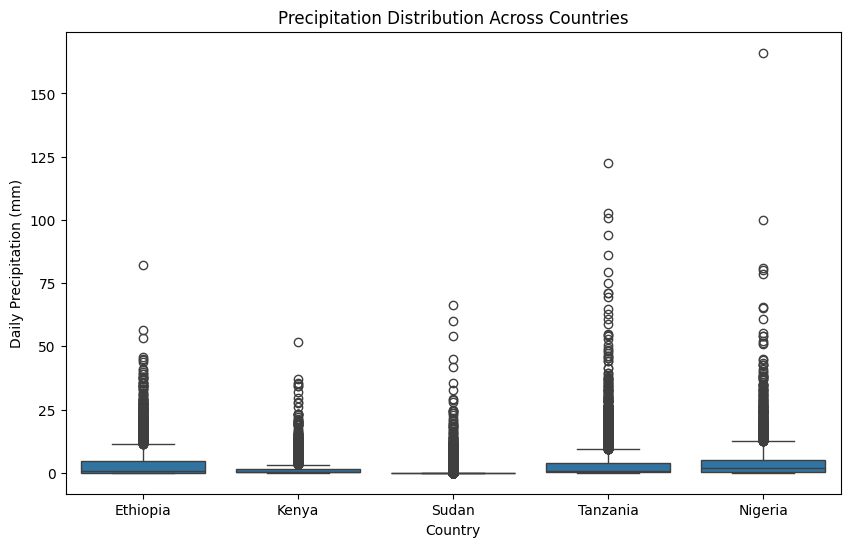

In [12]:
plt.figure(figsize=(10,6))

sns.boxplot(x="Country", y="PRECTOTCORR", data=df)

plt.title("Precipitation Distribution Across Countries")
plt.ylabel("Daily Precipitation (mm)")
plt.show()

In [13]:
prec_summary = df.groupby("Country")["PRECTOTCORR"].agg(["mean","median","std"])
prec_summary

,mean,median,std
Country,,,
Ethiopia,3.633795,0.82,6.289061
Kenya,1.468162,0.38,3.180228
Nigeria,4.213914,1.84,7.266742
Sudan,0.643875,0.00,3.057672
Tanzania,3.740256,0.64,8.003947


In [14]:
extreme_heat = df[df["T2M_MAX"] > 35]

heat_counts = extreme_heat.groupby(["Country","Year"]).size().reset_index(name="ExtremeHeatDays")

heat_counts.head()

,Country,Year,ExtremeHeatDays
0,Sudan,2015,280
1,Sudan,2016,252
2,Sudan,2017,266
3,Sudan,2018,248
4,Sudan,2019,251


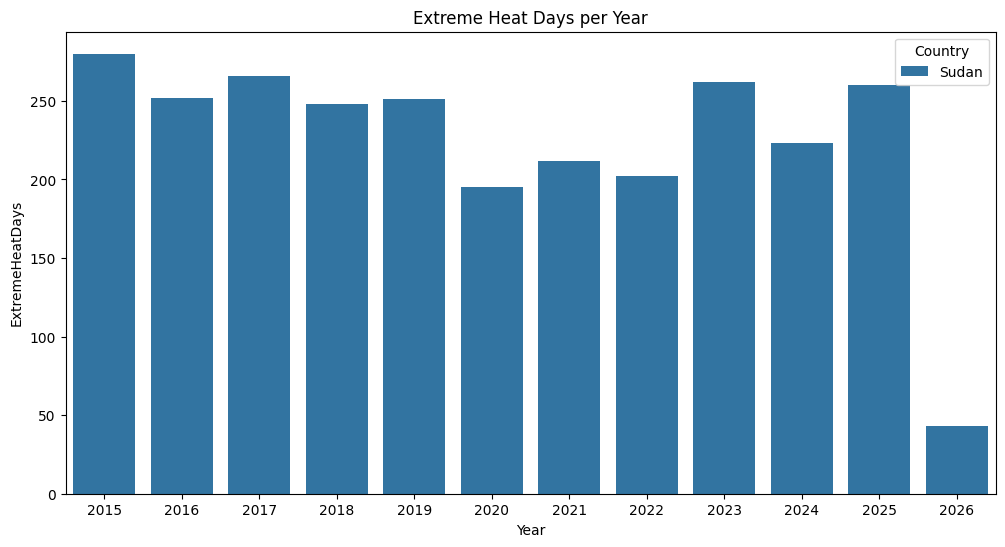

In [15]:
plt.figure(figsize=(12,6))

sns.barplot(data=heat_counts, x="Year", y="ExtremeHeatDays", hue="Country")

plt.title("Extreme Heat Days per Year")
plt.show()

In [16]:
df["DryDay"] = df["PRECTOTCORR"] < 1

In [17]:
dry_counts = df.groupby(["Country","Year"])["DryDay"].sum().reset_index()

dry_counts.rename(columns={"DryDay":"DryDays"}, inplace=True)

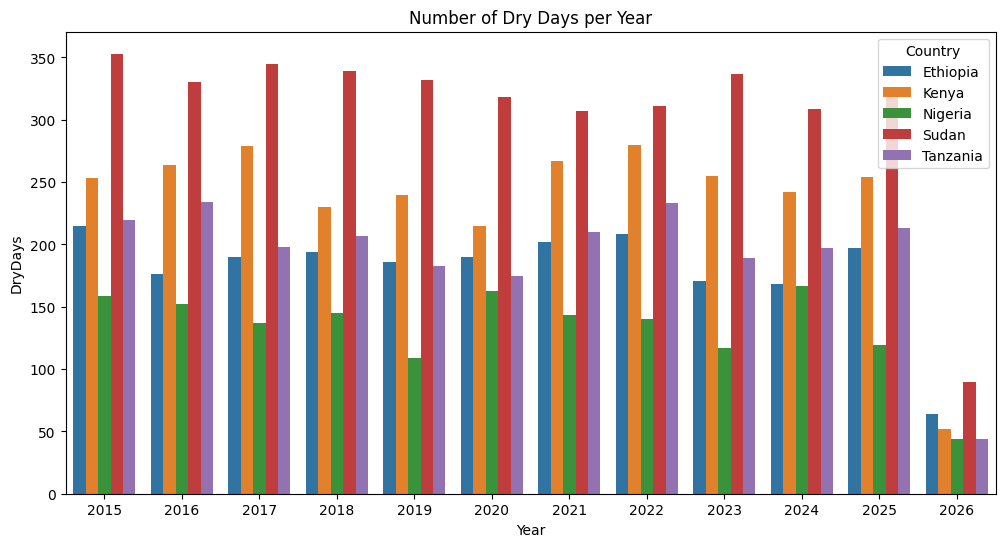

In [18]:
plt.figure(figsize=(12,6))

sns.barplot(data=dry_counts, x="Year", y="DryDays", hue="Country")

plt.title("Number of Dry Days per Year")
plt.show()

In [19]:
anova_result = f_oneway(
    ethiopia["T2M"].dropna(),
    kenya["T2M"].dropna(),
    sudan["T2M"].dropna(),
    tanzania["T2M"].dropna(),
    nigeria["T2M"].dropna()
)

anova_result

F_onewayResult(statistic=np.float64(18938.745697069917), pvalue=np.float64(0.0))

ANOVA test was conducted to determine whether average temperatures differ significantly across the five countries.
The test returned an F_statistic of 18938.75 and a p-value close to zero.
Since the pvalue is less than 0.05, we reject the null hypothesis and conclude that there are statistically significant differences in mean temperatures among Ethiopia, Kenya, Sudan, Tanzania, and Nigeria.
This indicates that each country experiences distinct climate conditions, which should be considered when evaluating regional climate vulnerability.

In [20]:
vulnerability = df.groupby("Country").agg(
    AvgTemp=("T2M","mean"),
    TempStd=("T2M","std"),
    AvgRain=("PRECTOTCORR","mean")
)

vulnerability.sort_values("AvgTemp", ascending=False)

,AvgTemp,TempStd,AvgRain
Country,,,
Sudan,28.759007,4.681305,0.643875
Tanzania,26.802422,1.325388,3.740256
Nigeria,26.656928,1.123335,4.213914
Kenya,20.427600,1.440824,1.468162
Ethiopia,16.068500,1.898050,3.633795


Based on the comparative analysis of average temperature, temperature
variability, and precipitation levels, Sudan appears to be the most
climate vulnerable country among the five analyzed.
Sudan records the highest average temperature (28.76°C) and the lowest
average rainfall (0.64 mm/day), indicating strong exposure to extreme
heat and drought conditions.
Nigeria and Tanzania experience relatively high temperatures and
significant rainfall levels, suggesting vulnerability to flooding
events and precipitation variability.
Kenya shows moderate temperatures but relatively lower rainfall,
which may increase drought risks in certain seasons.
Ethiopia exhibits the lowest average temperature among the countries,
likely due to its higher elevation, and maintains moderate rainfall
levels, suggesting comparatively lower heat stress but possible
rainfall variability impacts on agriculture.